<a href="https://colab.research.google.com/github/mklim0907/114-1-Deep-Learning-in-Biomedical-Optics-Imaging/blob/Homework4/111012062_%E6%9E%97%E6%98%8E%E5%BA%B7_HW4_model2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Library

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random
import time
import torch
import torch.nn as nn
import torch.optim as optims

from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.transforms.functional import InterpolationMode

In [ ]:
if torch.cuda.is_available():
    # 如果有 NVIDIA GPU
    device = torch.device("cuda")
    # 使用 torch.cuda.get_device_name(0) 來取得第一張卡的名稱
    print(f"正在使用 GPU: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    # 如果是 Apple Silicon Mac
    device = torch.device("mps")
    # MPS 目前沒有直接指令取得 M1/M2/M3 等具體型號
    print("正在使用 Apple Silicon GPU (MPS)")
else:
    # 如果以上皆非，則使用 CPU
    device = torch.device("cpu")
    print("GPU 不可用，正在使用 CPU")

GPU 不可用，正在使用 CPU


In [ ]:
# train loop
def train_one_epoch(model, device, criterion, optimizer, train_data_loader):
    epoch_loss = []
    epoch_acc = []
    start_time = time.time()

    model.train()

    for batch_idx, (images, labels) in enumerate (train_data_loader):
        images = images.to(device)
        labels = labels.to(device).float()
        optimizer.zero_grad()
        preds = model(images)
        loss = criterion(preds, labels.unsqueeze(1))

        # Calculating Loss
        epoch_loss.append(loss.item())

        # Calculating Metrics
        predicts = (preds > 0.5).float()
        predicts = predicts.view(-1)
        predicts = predicts.detach().cpu().numpy()
        labels = labels.detach().cpu().numpy()
        acc = accuracy_score(labels, predicts)

        epoch_acc.append(acc)

        # Backpropagation
        loss.backward()
        optimizer.step()

    # Overall Epoch Results
    end_time = time.time()
    total_time = end_time - start_time

    epoch_loss = np.mean(epoch_loss)
    epoch_acc = np.mean(epoch_acc) * 100

    return epoch_loss, epoch_acc, total_time

# validation loop
def val_one_epoch(model, device, criterion, val_data_loader, best_acc, save):
    epoch_loss = []
    epoch_acc = []
    start_time = time.time()

    model.eval()

    with torch.no_grad():
        for images, labels in val_data_loader:
            images = images.to(device)
            labels = labels.to(device).float()
            preds = model(images)

            # Calculating Loss
            loss = criterion(preds, labels.unsqueeze(1))
            epoch_loss.append(loss.item())

            # Calculating Metrics
            predicts = (preds > 0.5).float()
            predicts = predicts.view(-1)
            predicts = predicts.detach().cpu().numpy()
            labels = labels.detach().cpu().numpy()
            acc = accuracy_score(labels, predicts)
            epoch_acc.append(acc)

    # Overall Epoch Results
    end_time = time.time()
    total_time = end_time - start_time

    epoch_loss = np.mean(epoch_loss)
    epoch_acc = np.mean(epoch_acc) * 100

    # Saving best model
    if epoch_acc > best_acc:
        best_acc = epoch_acc
        torch.save(model.state_dict(), f"{save}.pth")

    return epoch_loss, epoch_acc, total_time, best_acc

# evaluate loop (test loop)
def evaluate(model, device, model_path, test_loader):
    try:
        model.load_state_dict(torch.load(model_path))
        print("Model weights loaded successfully.")
    except Exception as e:
        print("Warning: Failed to load model weights. Using randomly initialized weights instead.")
        print(e)

    model.to(device)
    model.eval()

    test_loss = []
    test_acc = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device).float()

            # Forward pass
            preds = model(images)

            # Calculating loss
            loss = criterion(preds, labels.unsqueeze(1))
            test_loss.append(loss.item())

            # Calculating accuracy
            predicts = (preds > 0.5).float()
            predicts = predicts.view(-1)
            predicts = predicts.detach().cpu().numpy()
            labels = labels.detach().cpu().numpy()
            acc = accuracy_score(labels, predicts)
            test_acc.append(acc)

    # Overall test results
    avg_test_loss = np.mean(test_loss)
    avg_test_acc = np.mean(test_acc) * 100

    print(f"Test Accuracy: {avg_test_acc:.2f}%")
    print(f"Test Loss: {avg_test_loss:.4f}")

    return avg_test_loss, avg_test_acc

# Data Preparation

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# define folder path for each set
train_path = '/content/drive/MyDrive/Colab Notebooks/114-1 Deep Learning in Biomedical Optics Imaging/HW3/chest_xray/train'
test_path = '/content/drive/MyDrive/Colab Notebooks/114-1 Deep Learning in Biomedical Optics Imaging/HW3/chest_xray/test'
val_path = '/content/drive/MyDrive/Colab Notebooks/114-1 Deep Learning in Biomedical Optics Imaging/HW3/chest_xray/val'

# define transformation
train_transform = transforms.Compose([
    transforms.Resize((256, 256), interpolation=InterpolationMode.BICUBIC),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])

common_transform = transforms.Compose([
    transforms.Resize((256, 256), interpolation=InterpolationMode.BICUBIC),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])

# create datasets
train_dataset = datasets.ImageFolder(train_path, transform=train_transform)
test_dataset = datasets.ImageFolder(test_path, transform=common_transform)
val_dataset = datasets.ImageFolder(val_path, transform=common_transform)

# create dataloaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Model

In [ ]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

# 1. 載入預訓練的 EfficientNet-B0
model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)

# --- 【修改點 A】 鎖住所有參數 ---
for param in model.parameters():
    param.requires_grad = False  # 這行是關鍵！告訴 PyTorch 不要更新這些參數
# ------------------------------

# 2. 修改層 (因為是新建立的層，預設 requires_grad=True，所以會被訓練)
# 修改第一層 (適應單通道)
model.conv1 = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)

# 2. 修改第一層卷積層以接受單通道 (灰階) 輸入
# EfficientNet 的第一層在 features[0][0]
# 原始設定: 3 input channels, 32 output channels, stride 2
model.features[0][0] = nn.Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)

# 3. 修改最後的全連接層 (分類器)
# model.classifier 結構通常是:
# (0): Dropout(p=0.2, inplace=True)
# (1): Linear(in_features=1280, out_features=1000, bias=True)
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_ftrs, 1)
model.to(device)

print(model)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 148MB/s] 


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

# Loop

In [ ]:
# hyperparameter
lr = 0.001
weight_decay = 0.001
params_to_update = [p for p in model.parameters() if p.requires_grad]
optimizer = optims.AdamW(params_to_update, lr=lr, weight_decay = weight_decay)
lr_scheduler = optims.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.1, patience=5, mode='max')
epochs = 10
criterion = nn.BCEWithLogitsLoss()

# save checkpoint
save = 'model'

In [ ]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_acc = 0.0
output_list = []

for epoch in range(epochs):
    train_loss, train_acc, train_time = train_one_epoch(model, device, criterion, optimizer, train_loader)
    val_loss, val_acc, val_time, best_acc = val_one_epoch(model, device, criterion, val_loader, best_acc, save)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    total_time = train_time + val_time
    output_str = f"Epoch {epoch+1}/{epochs} - loss: {train_loss:.4f} - train_acc: {train_acc:.2f}% - val_loss: {val_loss:.4f} - val_acc: {val_acc:.2f}% - time: {total_time:.2f}s"
    output_list.append(output_str)
    print(output_str)
    lr_scheduler.step(val_acc)

Epoch 1/10 - loss: 0.5254 - train_acc: 69.24% - val_loss: 0.7710 - val_acc: 50.00% - time: 764.97s
Epoch 2/10 - loss: 0.3449 - train_acc: 86.13% - val_loss: 0.7153 - val_acc: 50.00% - time: 275.43s
Epoch 3/10 - loss: 0.2873 - train_acc: 87.94% - val_loss: 0.5420 - val_acc: 68.75% - time: 274.48s
Epoch 4/10 - loss: 0.2518 - train_acc: 90.38% - val_loss: 0.5163 - val_acc: 81.25% - time: 273.41s
Epoch 5/10 - loss: 0.2296 - train_acc: 90.28% - val_loss: 0.6374 - val_acc: 75.00% - time: 277.75s
Epoch 6/10 - loss: 0.2135 - train_acc: 91.02% - val_loss: 0.3547 - val_acc: 87.50% - time: 274.60s
Epoch 7/10 - loss: 0.2033 - train_acc: 92.14% - val_loss: 0.7120 - val_acc: 62.50% - time: 275.82s
Epoch 8/10 - loss: 0.2031 - train_acc: 92.14% - val_loss: 0.4518 - val_acc: 81.25% - time: 277.77s
Epoch 9/10 - loss: 0.1865 - train_acc: 93.02% - val_loss: 0.4559 - val_acc: 75.00% - time: 273.41s
Epoch 10/10 - loss: 0.1806 - train_acc: 92.33% - val_loss: 0.5210 - val_acc: 68.75% - time: 285.02s


# Graph

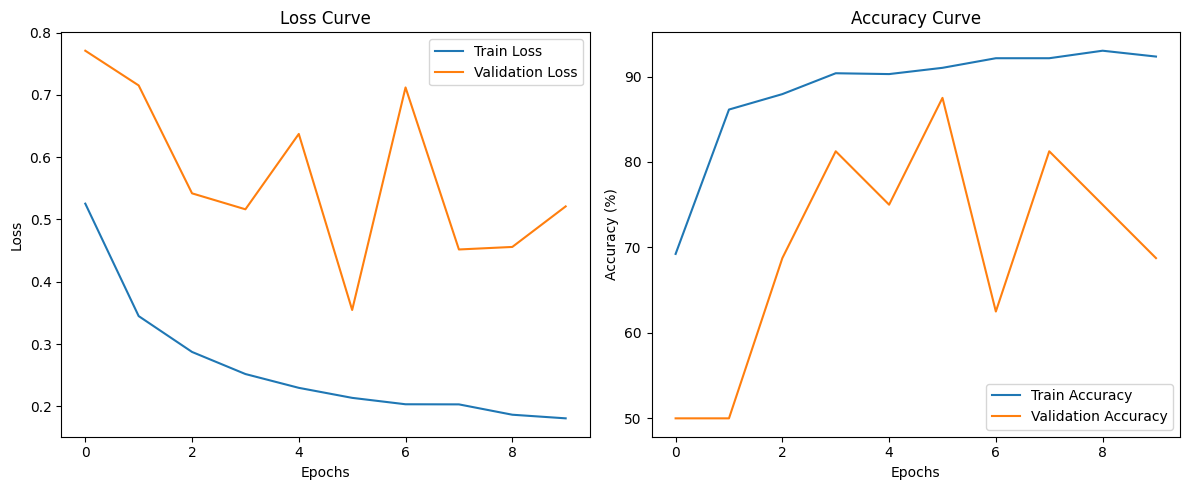

In [ ]:
plt.figure(figsize=(12, 5))

# loss graph
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# accuracy graph
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()

# show
plt.tight_layout()
plt.show()

# Evaluate

In [ ]:
model_path = 'model.pth'
avg_test_loss, avg_test_acc = evaluate(model, device, model_path, test_loader)

Model weights loaded successfully.
Test Accuracy: 86.51%
Test Loss: 0.3169
